# How Expressions Work

Mechanics of the expression system in `mplchart.expressions` (polars backend). This is the polars counterpart of the indicators page: with a pandas DataFrame charts are driven by `mplchart.indicators`, with a polars DataFrame by polars expressions — the charting layer is the same.

This page focuses on how expressions compose and plot; for a visual catalog of charts see the Gallery page.

In [1]:
from mplchart.chart import Chart
from mplchart.samples import sample_prices
from mplchart.primitives import Candlesticks, LinePlot, Stripes
from mplchart.expressions import SMA, EMA, RSI, MACD, OPEN, HIGH, LOW, CLOSE

prices = sample_prices(backend="polars")
prices.tail(3)

date,open,high,low,close,volume
date,f64,f64,f64,f64,i64
2025-11-13,274.109985,276.700012,272.089996,272.950012,49602800
2025-11-14,271.049988,275.959991,269.600006,272.410004,47399300
2025-11-17,268.815002,270.48999,265.730011,267.459991,42862157


## Factories return native polars expressions

`mplchart.expressions` contains expression *factories*: calling `SMA(20)` returns a plain `pl.Expr`, aliased with a slug label like `sma-20` (used for the legend). Being native expressions, they work anywhere polars accepts an expression — `select`, `with_columns`, filters — not just in charts. The module also exports `OPEN`, `HIGH`, `LOW`, `CLOSE`, `VOLUME` as shorthands for the corresponding `pl.col(...)`.

In [2]:
prices.select(CLOSE, SMA(20)).tail(3)

close,sma-20
f64,f64
272.950012,267.093961
272.410004,268.112178
267.459991,268.385876


Multi-output indicators return a single struct expression, one field per output. When plotting, the chart unnests the struct and draws each field.

In [3]:
prices.select(MACD()).tail(3)

macd-12-26-9
struct[3]
"{5.443428,5.575386,-0.131958}"
"{5.244467,5.509202,-0.264735}"
"{4.633946,5.334151,-0.700204}"


## Plotting and panes

Pass expressions to `plot()` alongside primitives, exactly like indicators. Everything draws on the *current* pane — use `pane()` (or the `Pane` primitive) to switch panes; overlays like `SMA` share the price scale, while oscillators like `RSI` typically get their own pane. Legend labels come from the expression alias.

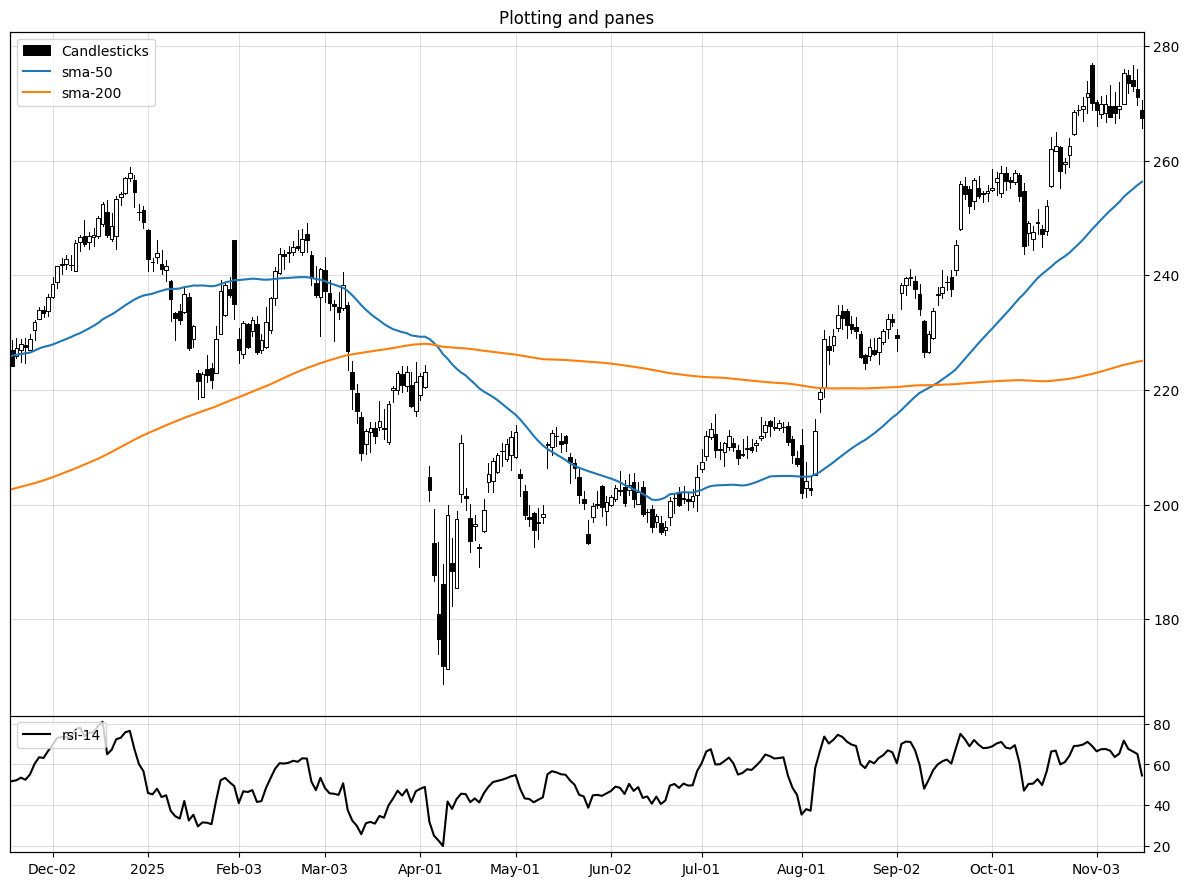

In [4]:
Chart(prices, title="Plotting and panes", max_bars=250).plot(
    Candlesticks(),
    SMA(50),
    SMA(200),
).pane("below").plot(
    RSI(14),
).show()

## Binding to primitives

By default expressions render with an automatic line plot. To control the rendering, pass the expression to a primitive like `LinePlot` (or `AreaPlot`, `BarPlot`, `Stripes`, `Markers`). The operator form `RSI(14) @ LinePlot(...)` is an equivalent alternative to the constructor form.

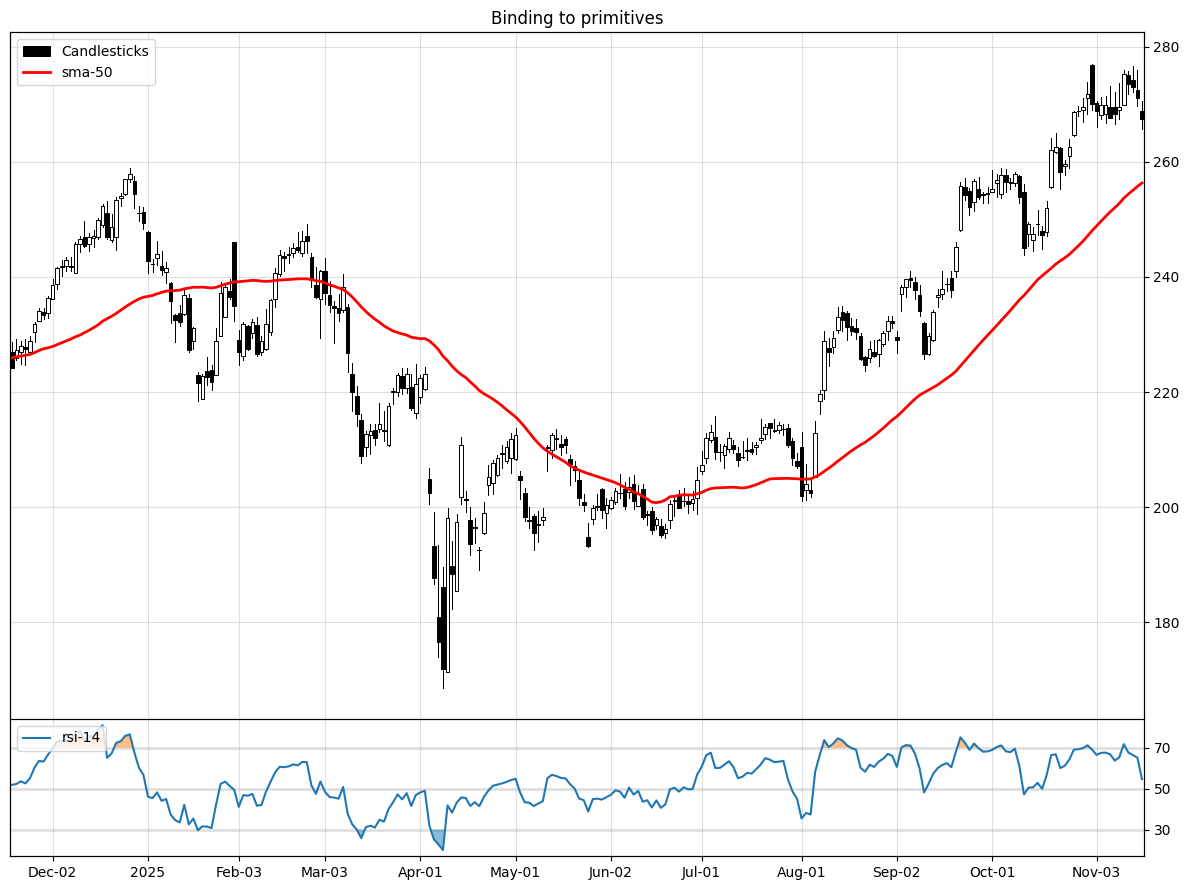

In [5]:
Chart(prices, title="Binding to primitives", max_bars=250).plot(
    Candlesticks(),
    LinePlot(SMA(50), color="red", width=2),
).pane("below", yticks=(30, 50, 70)).plot(
    LinePlot(RSI(14), overbought=70, oversold=30),
).show()

## Composing expressions

Every factory takes its source via `src` (default `CLOSE`), so composition is functional nesting rather than the `|` chaining used by pandas indicators: pass any expression as the source — a price shorthand, arithmetic on columns, or another factory's output.

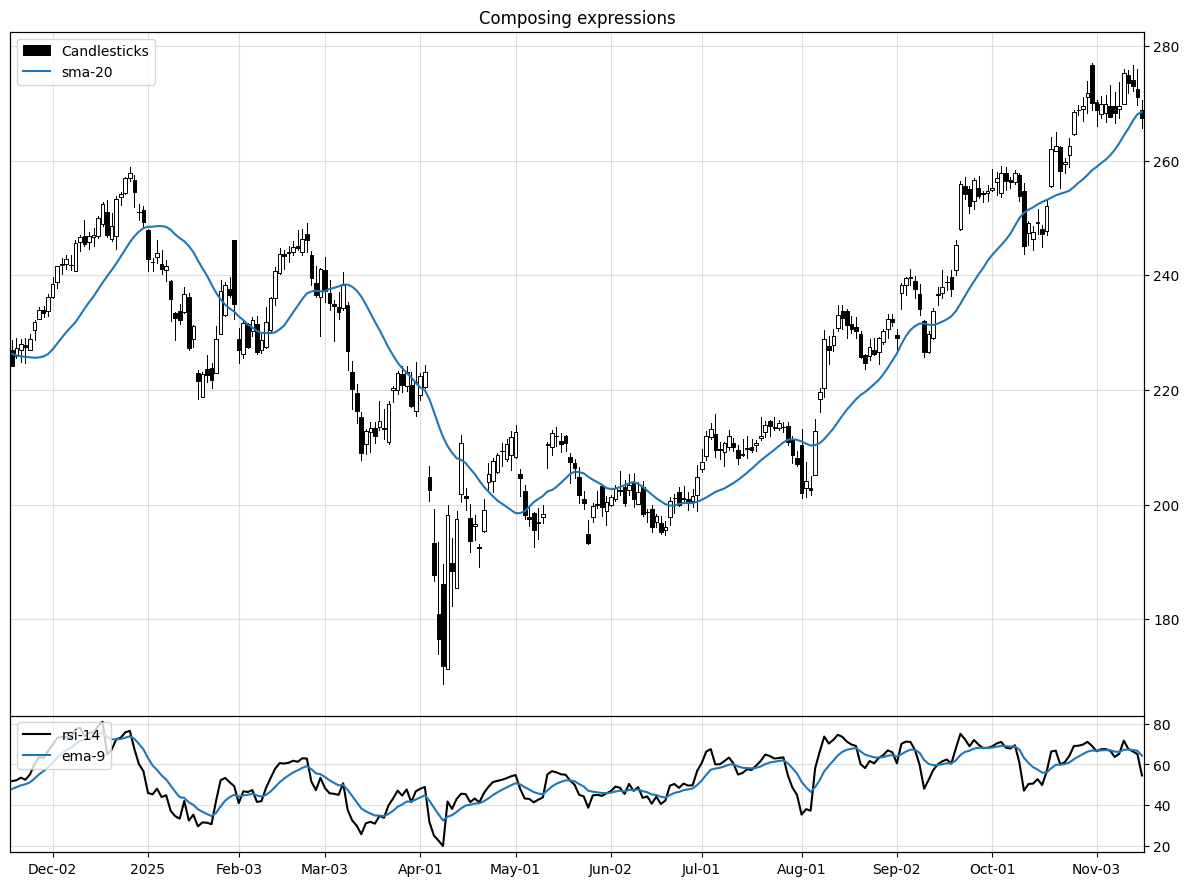

In [6]:
Chart(prices, title="Composing expressions", max_bars=250).plot(
    Candlesticks(),
    SMA(20, src=(HIGH + LOW) / 2),
).pane("below").plot(
    RSI(14),
    EMA(9, src=RSI(14)),
).show()

## Boolean composition

Expressions compare natively — `RSI(14) < 30` is just another `pl.Expr` — so condition-driven primitives like `Stripes` or `Markers` take the condition directly. (No `as_expr()` needed; that is the pandas-side bridge.)

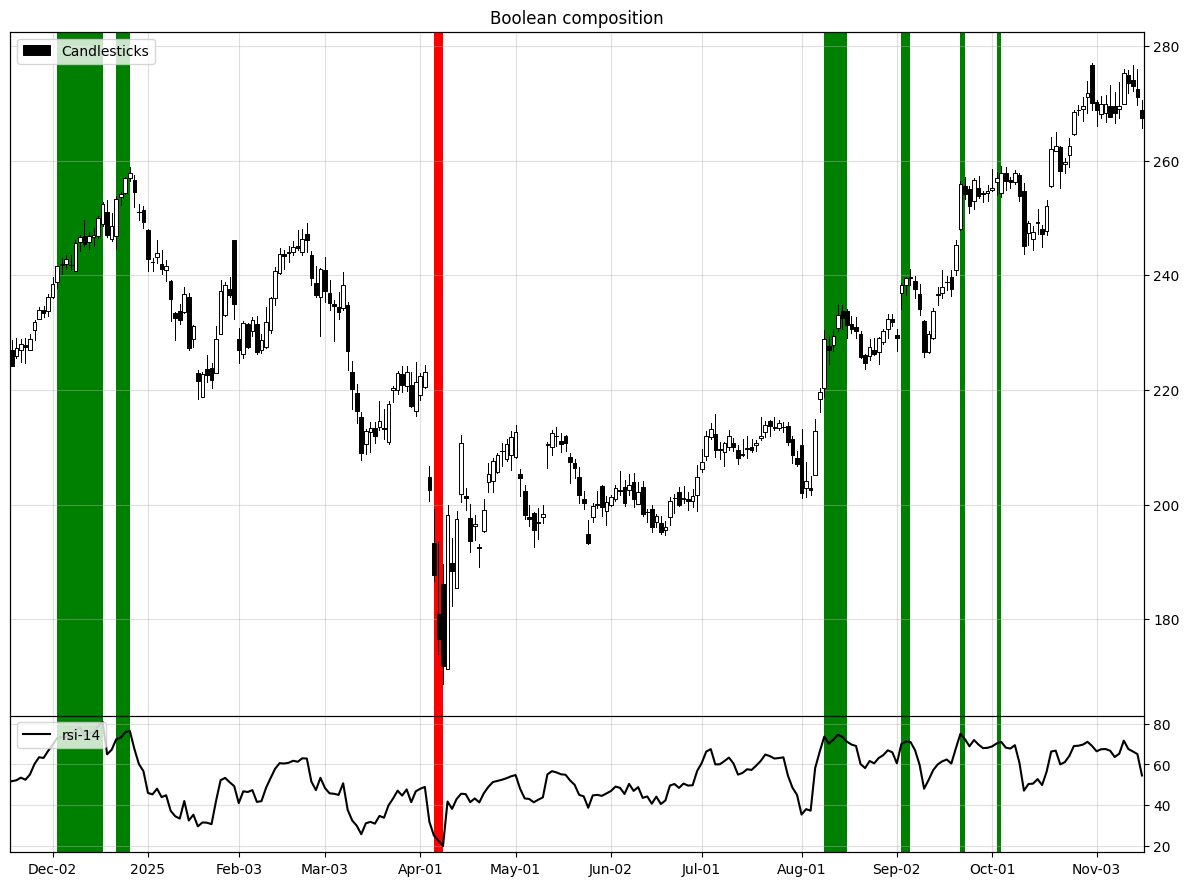

In [7]:
Chart(prices, title="Boolean composition", max_bars=250).plot(
    Candlesticks(),
    Stripes(RSI(14) < 30, color="red"),
    Stripes(RSI(14) > 70, color="green"),
).pane("below").plot(
    RSI(14),
).show()

## Custom expressions

Any polars expression plots directly — use `.alias(...)` to set the legend label.

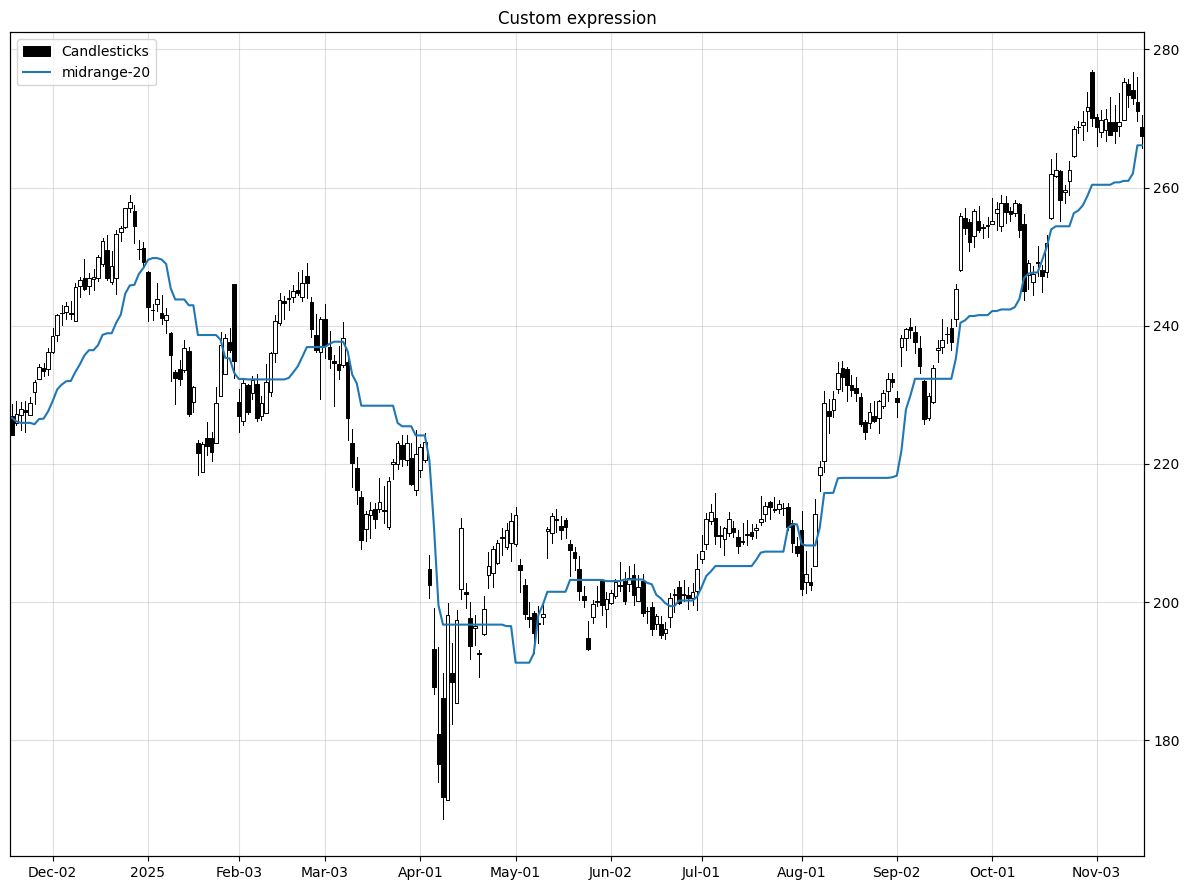

In [8]:
midrange = ((HIGH.rolling_max(20) + LOW.rolling_min(20)) / 2).alias("midrange-20")

Chart(prices, title="Custom expression", max_bars=250).plot(
    Candlesticks(),
    midrange,
).show()

The `wrap_expression` decorator turns a plain function into a factory like the built-ins: it accepts a leading `pl.Expr` as `src`, and aliases the result with a slug label built from the parameters (e.g. `zscore-20`).

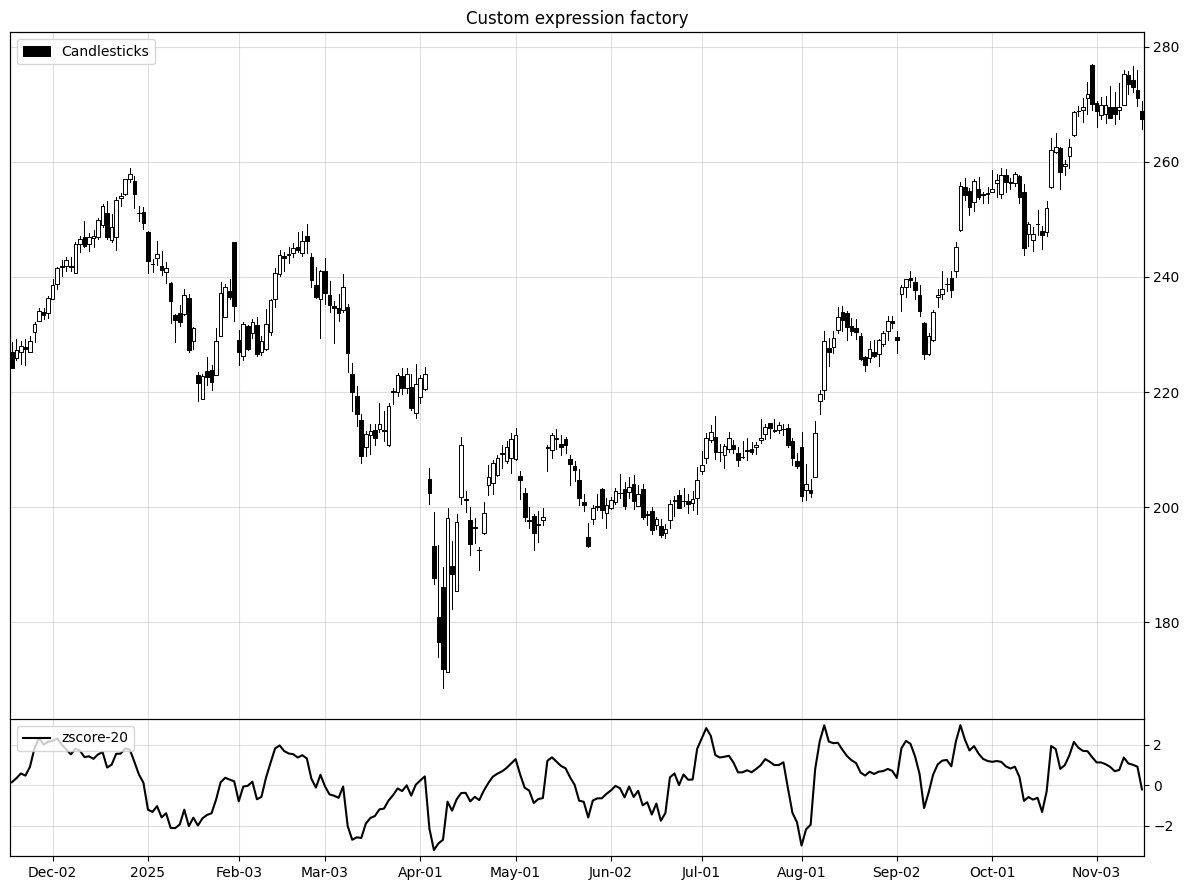

In [9]:
from mplchart.expressions import wrap_expression


@wrap_expression
def ZSCORE(period: int = 20, *, src=CLOSE):
    """Rolling z-score"""
    return (src - src.rolling_mean(period)) / src.rolling_std(period)


Chart(prices, title="Custom expression factory", max_bars=250).plot(
    Candlesticks(),
).pane("below").plot(
    ZSCORE(20),
).show()